In [15]:
import numpy as np
from pathlib import Path
from segmentflow import segment, view

Loading images...
--> Images loaded as 3D array:  (498, 508, 496)


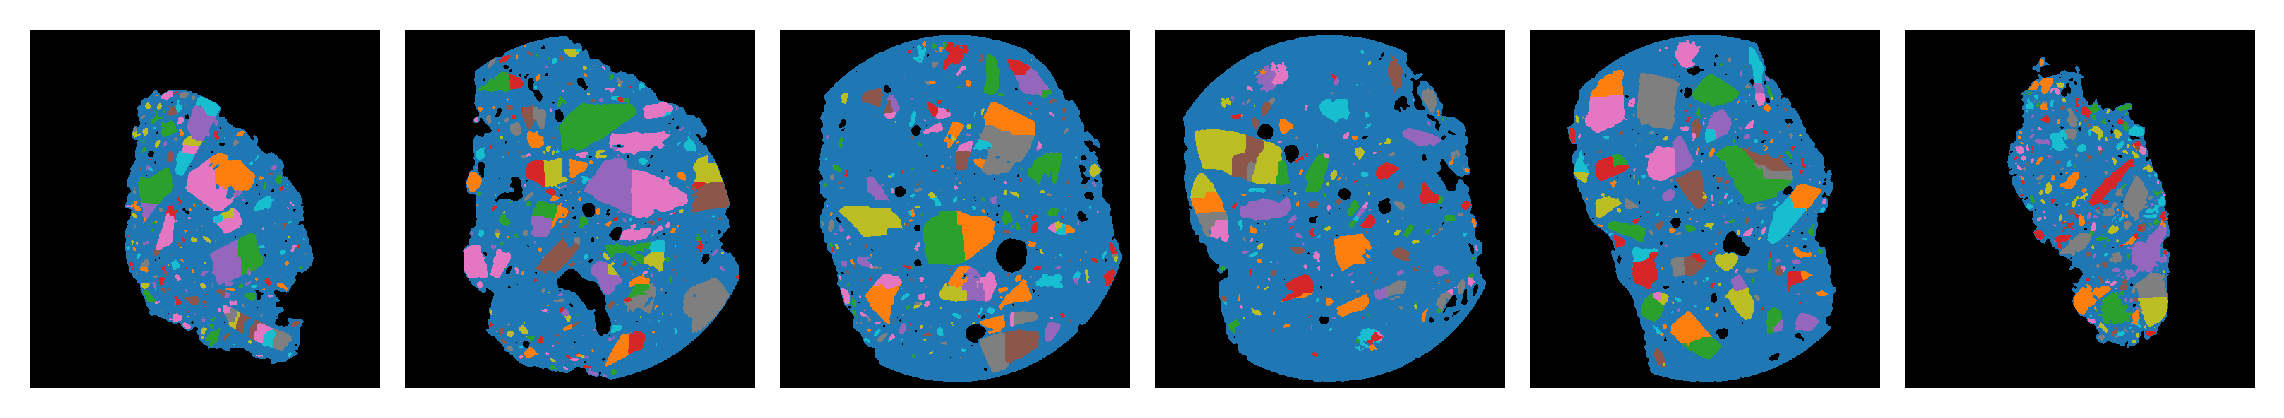

In [7]:
user = (
    'cgusb' if 'cgusb' in [f.stem for f in Path(r"C:\Users").iterdir()]
    else 'gusb'
)
img_dir = Path(
    fr'C:\Users\{user}\Research\mhe-analysis\results'
    fr'\prill_1_0.25-scale_segmented\prill_1_0.25-scale_labeled_voxels'
)
subvol_dir = Path(
    fr'C:\Users\{user}\Research\mhe-analysis\results'
    fr'\prill_1_0.25-scale_subvolumes'
)
labeled_imgs = segment.load_images(img_dir, file_suffix='.tif')
slices = list(range(50, 500, 75))
# fig, axes = view.vol_slices(labeled_imgs, nslices=10, imgs_per_row=5)
fig, axes = view.color_labels(labeled_imgs, slices=slices)

In [10]:
subvol_list = [p.stem for p in subvol_dir.iterdir()]
subvol_list

['00_subvol_downscale-5',
 '01_subvol_downscale-2',
 '02_subvol_downscale-2',
 '03_subvol_downscale-10',
 '04_subvol_downscale-5',
 '05_subvol_downscale-2',
 '06_subvol_downscale-5',
 '07_subvol_downscale-10',
 '08_subvol_downscale-10',
 '09_subvol_downscale-10']

In [ ]:
subvols = {}
for fn in subvol_list:
    subvol = segment.load_images(
        Path(subvol_dir) / fn / f'{fn}_labeled_voxels',
        file_suffix='.tif'
    )
    subvols[fn] = subvol

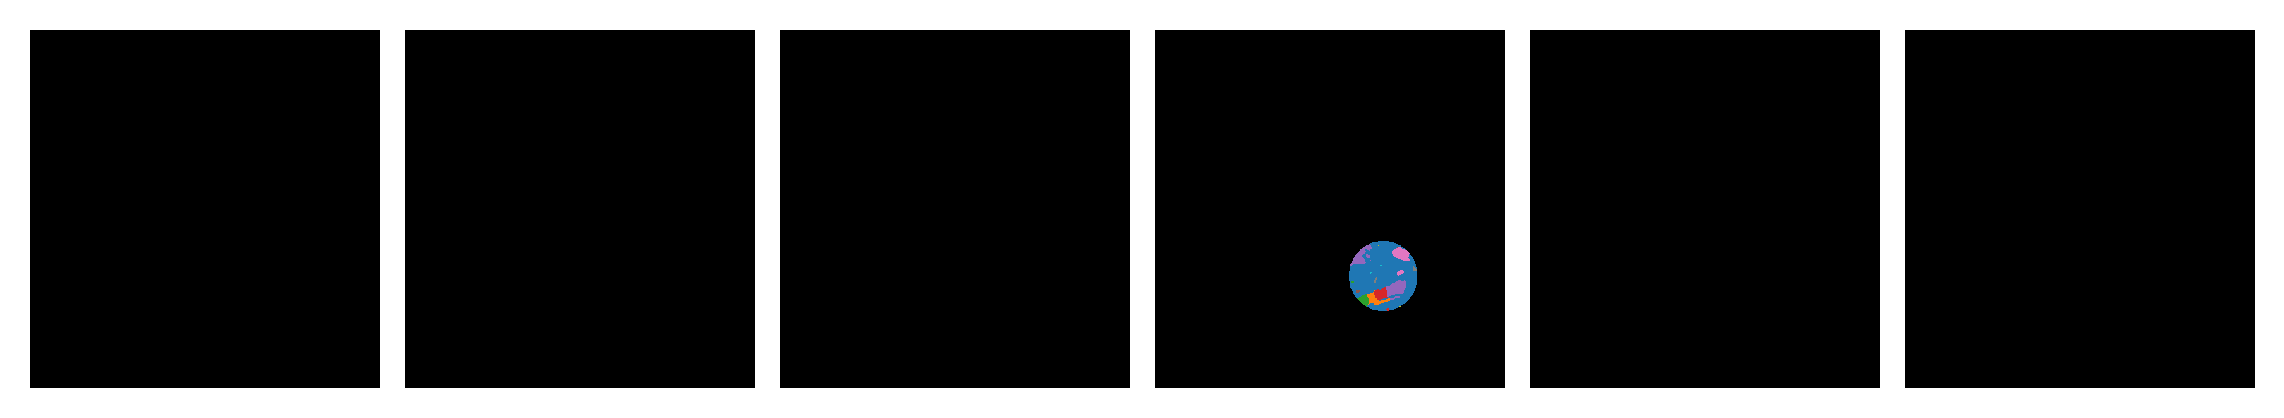

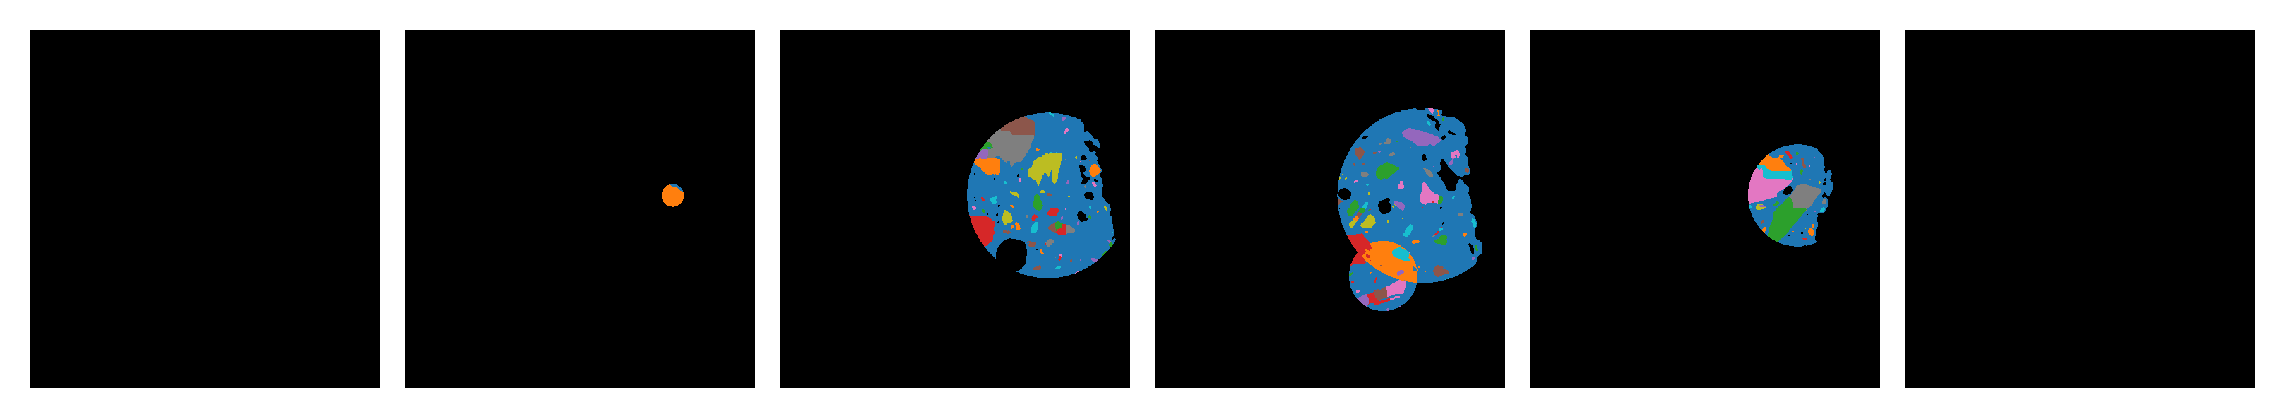

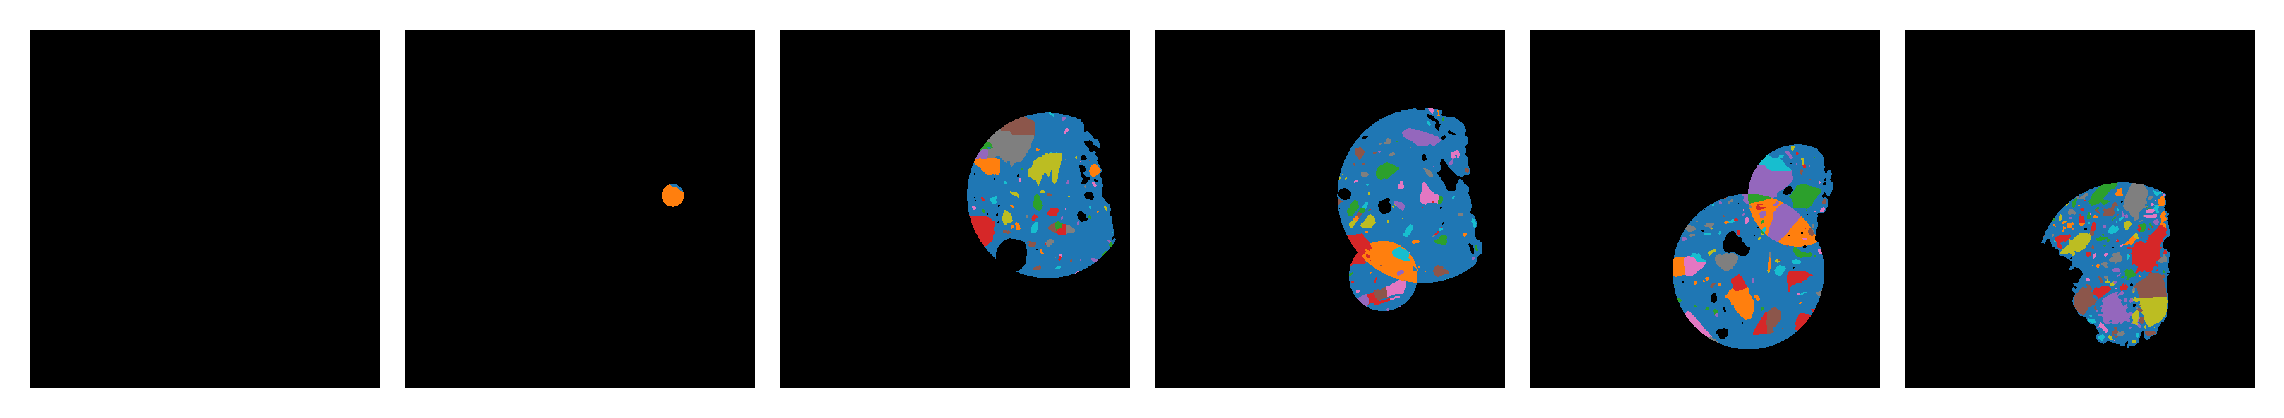

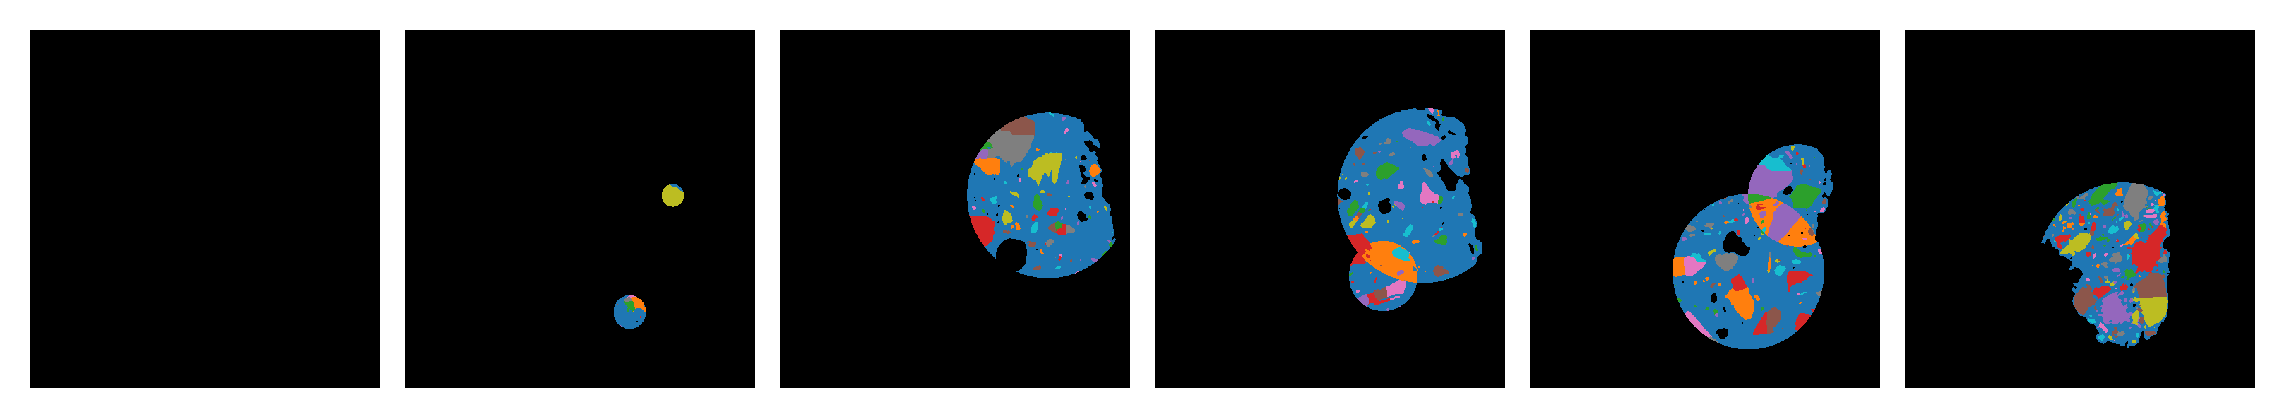

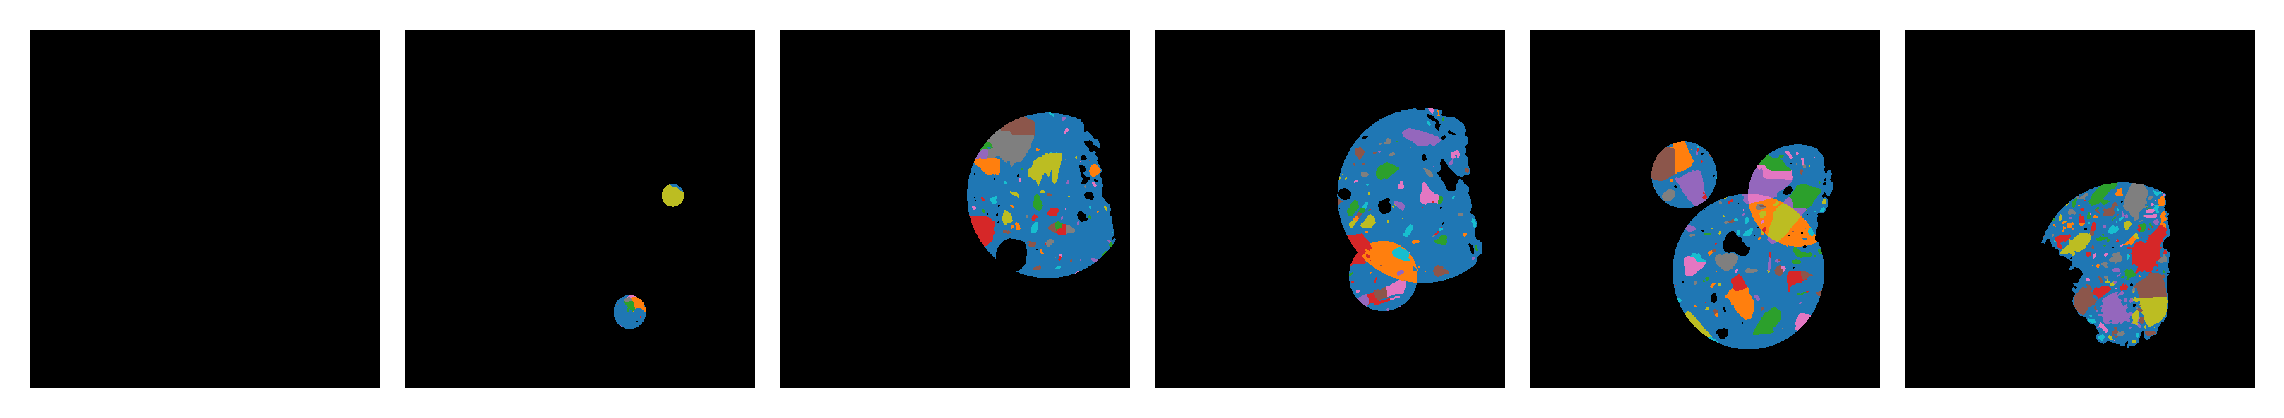

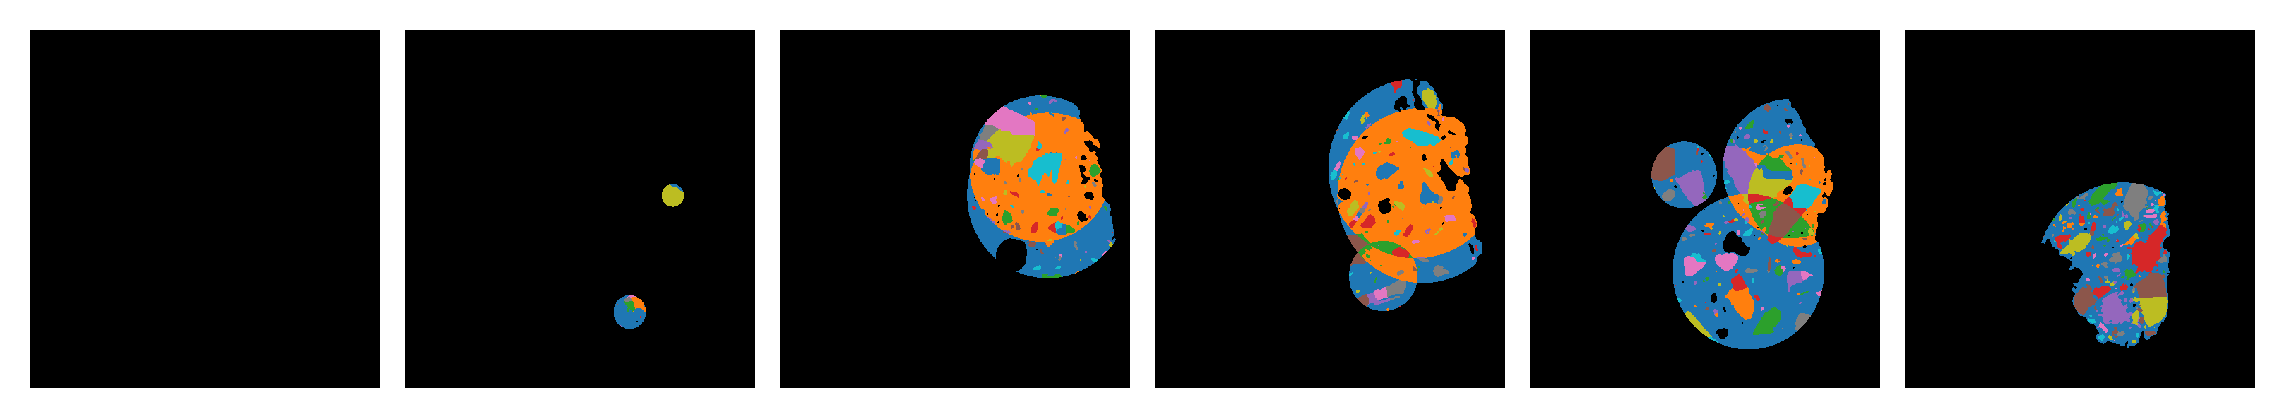

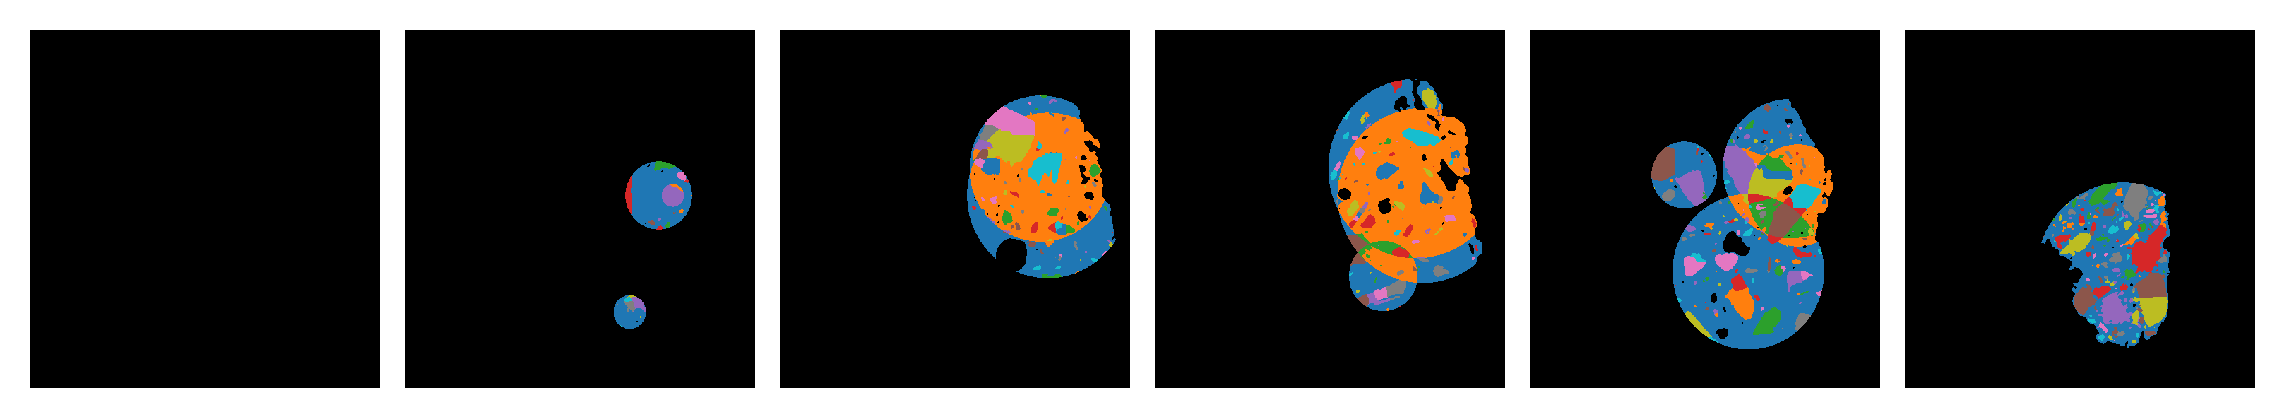

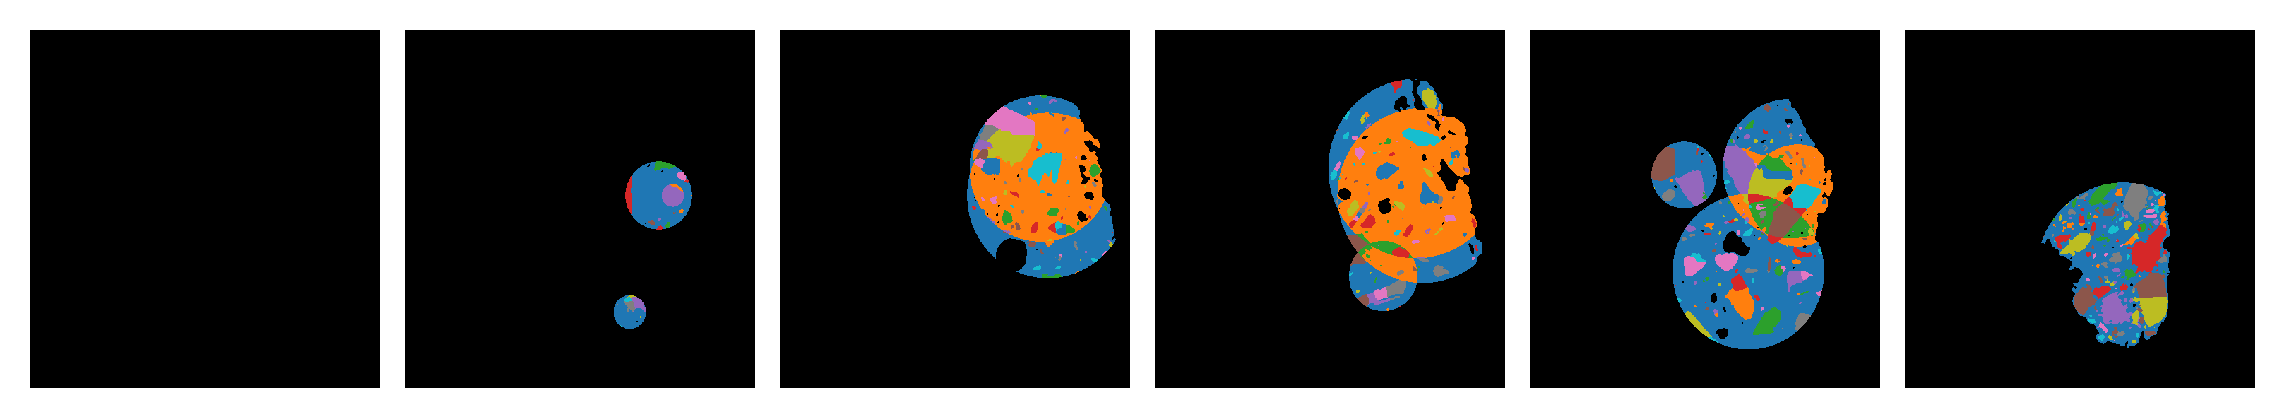

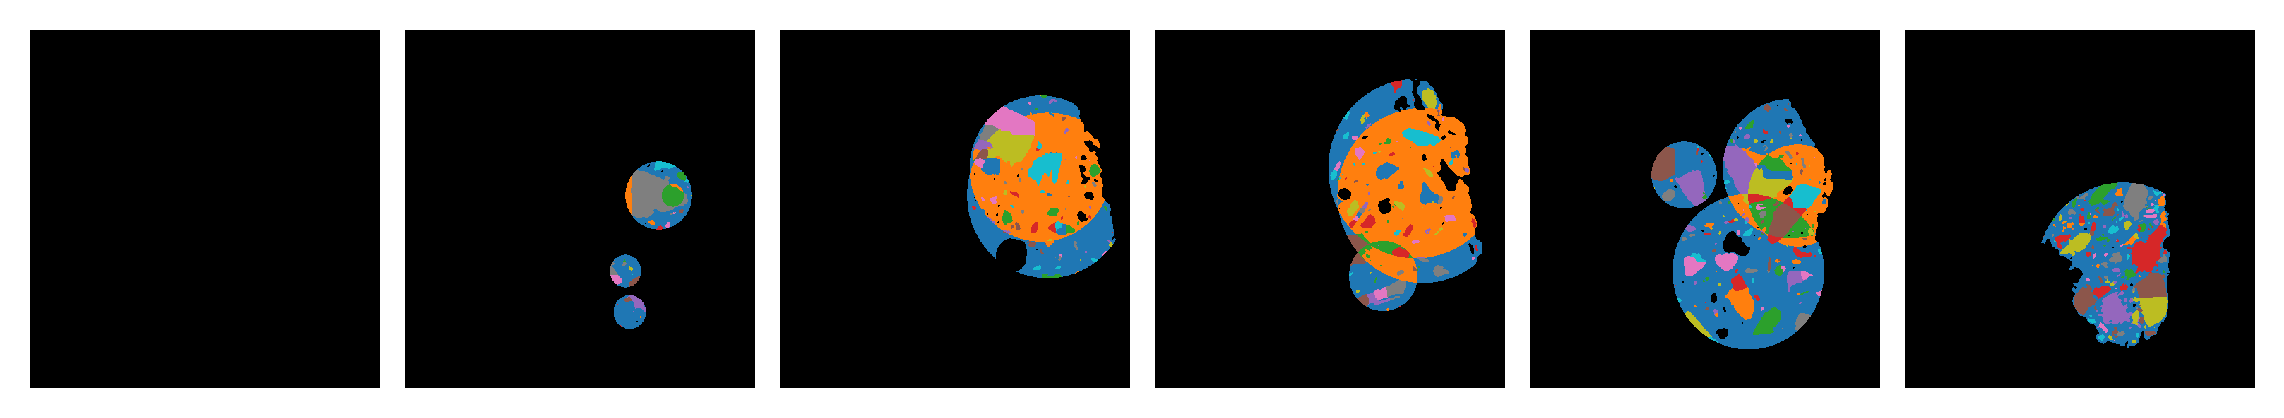

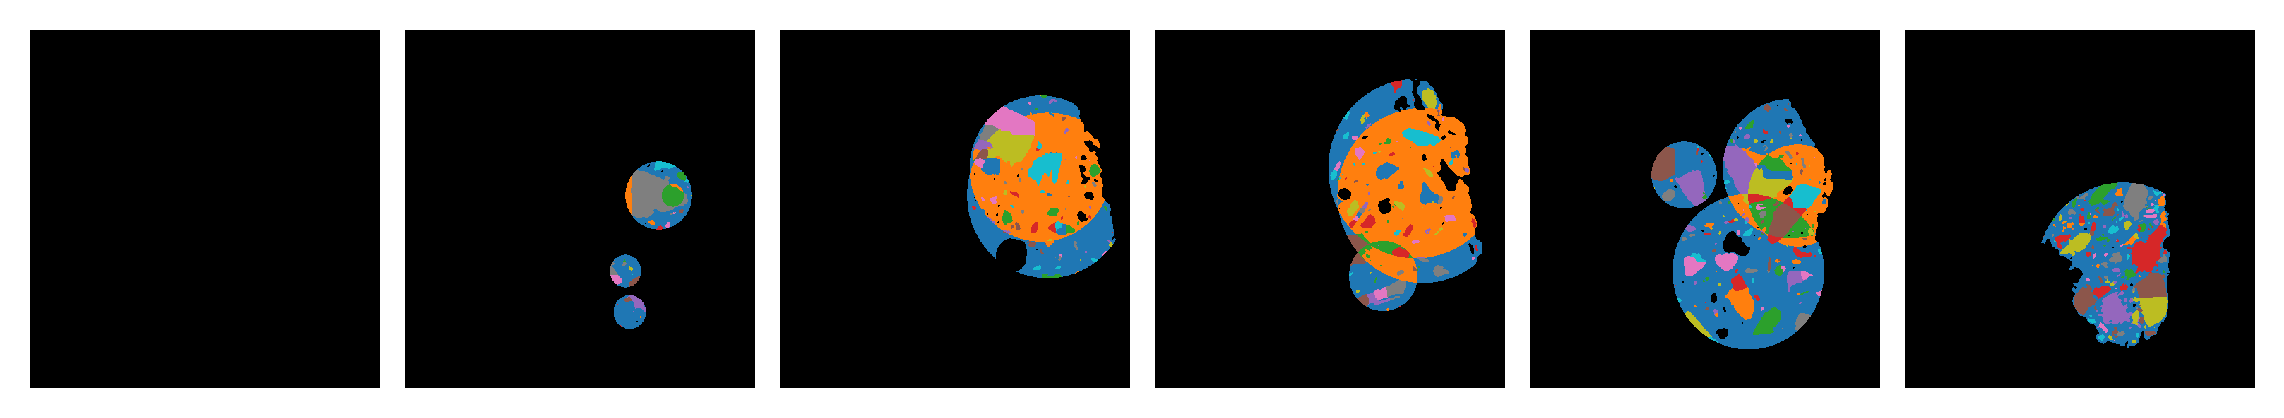

In [16]:
subvol_agg = np.zeros_like(labeled_imgs)
for fn in subvol_list:
    subvol = subvols[fn]
    subvol_agg = subvol_agg + subvol
    fig, axes = view.color_labels(subvol_agg, slices=slices)